# 5-Class Robust Skin Classifier (EfficientNet-B0 & ResNet-18)

Extends the 3-class triage model with two **rejection classes** so it declines to diagnose inputs
that aren't a target condition:

| Label | Class | Source |
|---|---|---|
| 0 | Fungal | PASSION |
| 1 | Scabies | PASSION |
| 2 | Eczema | PASSION |
| 3 | healthy_skin | "Oily/Dry/Normal" Kaggle dataset (normal folders) |
| 4 | not_skin | CIFAR-100 (torchvision, auto-download) |



In [1]:
import os, random, numpy as np, torch
import torch.nn as nn, torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             accuracy_score, f1_score)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## Cell 2 — Paths & config



In [ ]:

PASSION_ROOT = "/kaggle/input/datasets/mathiaskabango/passion-dataset/PASSION_MICCAI_2024"

IMG_DIR  = os.path.join(PASSION_ROOT, "images")
CSV_PATH = os.path.join(PASSION_ROOT, "label.csv")


HEALTHY_BASE = "/kaggle/input/datasets/shakyadissanayake/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types"

NOT_SKIN_DIR = "/kaggle/working/not_skin"


USE_HEALTHY = True
N_NOT_SKIN  = 1000
N_HEALTHY   = 600


if USE_HEALTHY:
    CLASS_NAMES = ['Fungal','Scabies','Eczema','healthy_skin','not_skin']
    HEALTHY_LABEL, NOT_SKIN_LABEL, NUM_CLASSES = 3, 4, 5
else:
    CLASS_NAMES = ['Fungal','Scabies','Eczema','not_skin']
    HEALTHY_LABEL, NOT_SKIN_LABEL, NUM_CLASSES = None, 3, 4
PASSION_CLASSES = {'Fungal':0, 'Scabies':1, 'Eczema':2}
print("Classes:", CLASS_NAMES)


Classes: ['Fungal', 'Scabies', 'Eczema', 'healthy_skin', 'not_skin']


##  Build the `not_skin` set from CIFAR-100 

In [3]:
cifar = datasets.CIFAR100(root="/kaggle/working/cifar", train=True, download=True)
os.makedirs(NOT_SKIN_DIR, exist_ok=True)
random.seed(42)
for i, idx in enumerate(random.sample(range(len(cifar)), N_NOT_SKIN)):
    cifar[idx][0].save(os.path.join(NOT_SKIN_DIR, f"notskin_{i:04d}.png"))
print(f"Saved {N_NOT_SKIN} not_skin images.")


100%|██████████| 169M/169M [00:02<00:00, 74.9MB/s] 


Saved 1000 not_skin images.


## Gather rejection-class files & split them

In [4]:
def list_imgs_multi(dirs, cap=None):
    files = []
    for d in dirs:
        if os.path.isdir(d):
            files += [os.path.join(d, f) for f in os.listdir(d)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
    files.sort()
    return files[:cap] if cap else files

# healthy = the three normal/ folders pooled
HEALTHY_DIRS = []
if USE_HEALTHY:
    for split in ["train","valid","test"]:
        cand = os.path.join(HEALTHY_BASE, split, "normal")
        if os.path.isdir(cand):
            HEALTHY_DIRS.append(cand)
    print("Healthy folders:", HEALTHY_DIRS)

healthy_all = list_imgs_multi(HEALTHY_DIRS, N_HEALTHY) if USE_HEALTHY else []
notskin_all = list_imgs_multi([NOT_SKIN_DIR], N_NOT_SKIN)
print(f"healthy_skin images: {len(healthy_all)} | not_skin images: {len(notskin_all)}")

def split3(lst, seed=42):
    if not lst: return [], [], []
    tr, tmp = train_test_split(lst, test_size=0.20, random_state=seed)
    va, te  = train_test_split(tmp, test_size=0.50, random_state=seed)
    return tr, va, te

h_tr,h_va,h_te = split3(healthy_all)
n_tr,n_va,n_te = split3(notskin_all)
print(f"healthy split: {len(h_tr)}/{len(h_va)}/{len(h_te)} | notskin split: {len(n_tr)}/{len(n_va)}/{len(n_te)}")


Healthy folders: ['/kaggle/input/datasets/shakyadissanayake/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/train/normal', '/kaggle/input/datasets/shakyadissanayake/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/valid/normal', '/kaggle/input/datasets/shakyadissanayake/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/test/normal']
healthy_skin images: 600 | not_skin images: 1000
healthy split: 480/60/60 | notskin split: 800/100/100


## PASSION (3 classes) load + patient-level split

In [5]:
pdf = pd.read_csv(CSV_PATH)
pdf = pdf[pdf['conditions_PASSION'].isin(['Fungal','Scabies','Eczema'])].reset_index(drop=True)
print("PASSION 3-class rows:", len(pdf))

pids = pdf['subject_id'].unique()
tr_ids, tmp_ids = train_test_split(pids, test_size=0.20, random_state=42)
va_ids, te_ids  = train_test_split(tmp_ids, test_size=0.50, random_state=42)
tr_df = pdf[pdf['subject_id'].isin(tr_ids)]
va_df = pdf[pdf['subject_id'].isin(va_ids)]
te_df = pdf[pdf['subject_id'].isin(te_ids)]

# leakage check
print("overlaps:",
      len(set(tr_ids)&set(va_ids)), len(set(tr_ids)&set(te_ids)), len(set(va_ids)&set(te_ids)))


PASSION 3-class rows: 1464
overlaps: 0 0 0


## Mixed dataset (PASSION + healthy + not_skin) and loaders

In [6]:
class MixedSkinDataset(Dataset):
    def __init__(self, passion_df, img_dir, healthy_files, notskin_files, transform=None):
        self.transform = transform
        self.samples = []
        lookup = {r['subject_id']: (PASSION_CLASSES[r['conditions_PASSION']], r['fitzpatrick'])
                  for _, r in passion_df.iterrows()
                  if r['conditions_PASSION'] in PASSION_CLASSES}
        for fn in os.listdir(img_dir):
            if not fn.endswith(('.jpg','.jpeg','.png')) or '(' in fn: continue
            sid = fn.rsplit('_', 1)[0]
            if sid in lookup:
                lbl, fz = lookup[sid]
                self.samples.append((os.path.join(img_dir, fn), lbl, fz))
        if USE_HEALTHY:
            for p in healthy_files: self.samples.append((p, HEALTHY_LABEL, -1))
        for p in notskin_files:     self.samples.append((p, NOT_SKIN_LABEL, -1))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label, fitz = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, fitz

train_tf = transforms.Compose([
    transforms.Resize((256,256)), transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_dataset = MixedSkinDataset(tr_df, IMG_DIR, h_tr, n_tr, train_tf)
val_dataset   = MixedSkinDataset(va_df, IMG_DIR, h_va, n_va, eval_tf)
test_dataset  = MixedSkinDataset(te_df, IMG_DIR, h_te, n_te, eval_tf)

print("Train:", len(train_dataset), "| Val:", len(val_dataset), "| Test:", len(test_dataset))
print("Train label dist:", Counter([l for _,l,_ in train_dataset.samples]))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)


Train: 4377 | Val: 574 | Test: 533
Train label dist: Counter({1: 1259, 0: 950, 2: 888, 4: 800, 3: 480})


## Models + shared train / evaluate functions

In [7]:
def build_efficientnet(n=NUM_CLASSES):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, n)); return m
def build_resnet18(n=NUM_CLASSES):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, n)); return m
BUILDERS = {"EfficientNet-B0": build_efficientnet, "ResNet-18": build_resnet18}

def run_epoch(model, loader, crit, opt=None):
    train = opt is not None
    model.train() if train else model.eval()
    tot=correct=total=0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            if train: opt.zero_grad()
            out = model(images); loss = crit(out, labels)
            if train: loss.backward(); opt.step()
            tot += loss.item()*images.size(0)
            correct += (out.argmax(1)==labels).sum().item(); total += images.size(0)
    return tot/total, correct/total

def train_model(tag, build_fn, epochs=50, patience=7):
    model = build_fn().to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=3, factor=0.2)
    best, no_imp = 0.0, 0; path=f'{tag}_5class_best.pth'
    for ep in range(epochs):
        trl,tra = run_epoch(model, train_loader, crit, opt)
        val,vaa = run_epoch(model, val_loader, crit)
        sch.step(val)
        if vaa>best: best=vaa; torch.save(model.state_dict(), path); no_imp,flag=0,"OK"
        else: no_imp+=1; flag=f"({no_imp}/{patience})"
        print(f"[{tag}] Ep {ep+1:02d} | tr_acc {tra:.3f} | va_acc {vaa:.3f} {flag}")
        if no_imp>=patience: print(f"[{tag}] early stop"); break
    model.load_state_dict(torch.load(path)); print(f"[{tag}] best val {best:.4f}")
    return model, best

def full_evaluate(model, loader, tag):
    model.eval(); P,L,F=[],[],[]
    with torch.no_grad():
        for images, labels, fitz in loader:
            out = model(images.to(device))
            P.extend(out.argmax(1).cpu().numpy()); L.extend(labels.numpy())
            F.extend([f.item() for f in fitz])
    P,L,F = map(np.array,(P,L,F))
    acc=accuracy_score(L,P); mf1=f1_score(L,P,average="macro")
    pr,rc,f1,sup = precision_recall_fscore_support(L,P,labels=list(range(NUM_CLASSES)),zero_division=0)
    print(f"\n{'='*60}\n  {tag} - Test Acc {acc:.4f} | Macro-F1 {mf1:.4f}\n{'='*60}")
    print(f"{'Class':<14}{'Prec':>9}{'Recall':>9}{'F1':>9}{'Support':>9}\n"+"-"*50)
    for i,n in enumerate(CLASS_NAMES):
        print(f"{n:<14}{pr[i]:>9.3f}{rc[i]:>9.3f}{f1[i]:>9.3f}{sup[i]:>9}")
    fc,ft=defaultdict(int),defaultdict(int)
    for p,l,fz in zip(P,L,F):
        if fz in (4,5,6):
            ft[fz]+=1
            if p==l: fc[fz]+=1
    fa={fz:fc[fz]/ft[fz] for fz in sorted(ft) if ft[fz]>0}
    disp=(max(fa.values())-min(fa.values())) if len(fa)>1 else 0.0
    print("\nFitzpatrick accuracy (disease images only):")
    for fz,a in fa.items(): print(f"  Type {fz}: {a:.4f}")
    print(f"Dark-skin disparity: {disp:.4f}")
    return {"model":tag,"accuracy":round(float(acc),4),"macro_f1":round(float(mf1),4),
            "per_class":{CLASS_NAMES[i]:{"precision":round(float(pr[i]),4),
                "recall":round(float(rc[i]),4),"f1":round(float(f1[i]),4),
                "support":int(sup[i])} for i in range(NUM_CLASSES)},
            "dark_skin_disparity":round(float(disp),4),"_preds":P,"_labels":L}


## Train & evaluate BOTH architectures


############################################################
# EfficientNet-B0
############################################################
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limi

[EfficientNet-B0] Ep 01 | tr_acc 0.722 | va_acc 0.826 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[EfficientNet-B0] Ep 02 | tr_acc 0.827 | va_acc 0.828 OK


...

[EfficientNet-B0] Ep 20 | tr_acc 0.981 | va_acc 0.864 (5/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[EfficientNet-B0] Ep 21 | tr_acc 0.983 | va_acc 0.861 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[EfficientNet-B0] Ep 22 | tr_acc 0.980 | va_acc 0.861 (7/7)
[EfficientNet-B0] early stop
[EfficientNet-B0] best val 0.8693

  EfficientNet-B0 - Test Acc 0.8537 | Macro-F1 0.8683
Class              Prec   Recall       F1  Support
--------------------------------------------------
Fungal            0.761    0.754    0.758      114
Scabies           0.853    0.875    0.864      152
Eczema            0.731    0.710    0.720      107
healthy_skin      1.000    1.000    1.000       60
not_skin          1.000    1.000    1.000      100

Fitzpatrick accuracy (disease images only):
  Type 4: 0.7475
  Type 5: 0.7951
  Type 6: 0.8095
Dark-skin disparity: 0.0620


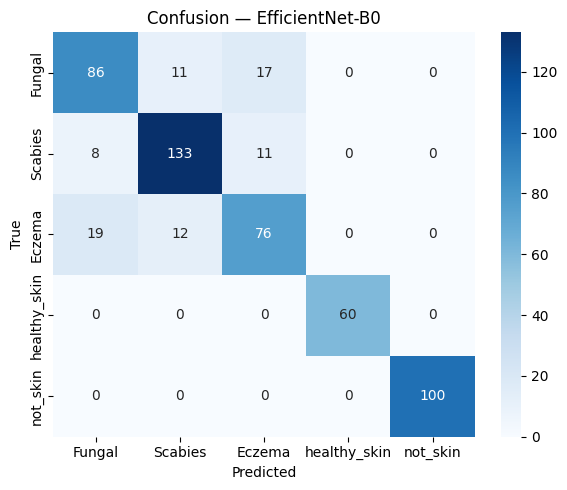


############################################################
# ResNet-18
############################################################
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limi

[ResNet-18] Ep 01 | tr_acc 0.707 | va_acc 0.749 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[ResNet-18] Ep 02 | tr_acc 0.769 | va_acc 0.760 OK


...

[ResNet-18] Ep 15 | tr_acc 0.940 | va_acc 0.841 (5/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[ResNet-18] Ep 16 | tr_acc 0.946 | va_acc 0.848 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DO

[ResNet-18] Ep 17 | tr_acc 0.952 | va_acc 0.829 (7/7)
[ResNet-18] early stop
[ResNet-18] best val 0.8537

  ResNet-18 - Test Acc 0.8311 | Macro-F1 0.8473
Class              Prec   Recall       F1  Support
--------------------------------------------------
Fungal            0.802    0.675    0.733      114
Scabies           0.768    0.895    0.827      152
Eczema            0.700    0.654    0.676      107
healthy_skin      1.000    1.000    1.000       60
not_skin          1.000    1.000    1.000      100

Fitzpatrick accuracy (disease images only):
  Type 4: 0.7172
  Type 5: 0.7869
  Type 6: 0.7143
Dark-skin disparity: 0.0726


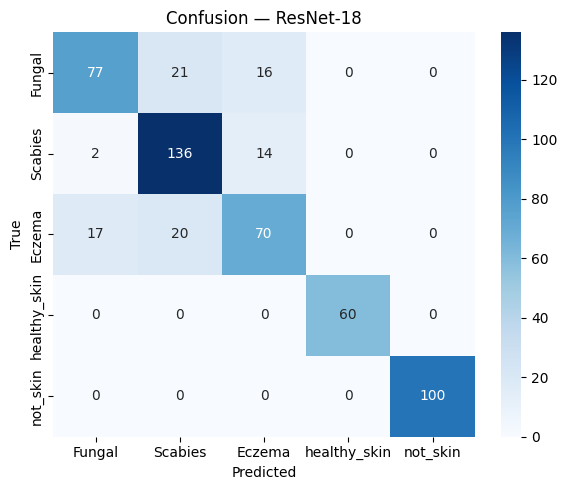

In [8]:
results={}
for tag, fn in BUILDERS.items():
    print(f"\n{'#'*60}\n# {tag}\n{'#'*60}")
    model, best = train_model(tag, fn)
    res = full_evaluate(model, test_loader, tag)
    res["best_val"]=round(best,4); res["params"]=sum(p.numel() for p in model.parameters())
    results[tag]=res
    cm=confusion_matrix(res["_labels"],res["_preds"],labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion — {tag}")
    plt.tight_layout(); plt.savefig(f"{tag}_5class_confusion.png",dpi=150,bbox_inches="tight"); plt.show()


## table + save results

In [9]:
import json
rows=[]
for tag,r in results.items():
    rows.append({"Model":tag,"Best Val":r["best_val"],"Test Acc":r["accuracy"],
        "Macro-F1":r["macro_f1"],
        "not_skin recall":r["per_class"]["not_skin"]["recall"],
        "healthy recall":(r["per_class"]["healthy_skin"]["recall"] if "healthy_skin" in r["per_class"] else None),
        "Fungal recall":r["per_class"]["Fungal"]["recall"],
        "Scabies recall":r["per_class"]["Scabies"]["recall"],
        "Eczema recall":r["per_class"]["Eczema"]["recall"],
        "Dark disparity":r["dark_skin_disparity"],"Params (M)":round(r["params"]/1e6,2)})
comp=pd.DataFrame(rows).sort_values("Test Acc",ascending=False)
print(comp.to_string(index=False)); comp.to_csv("5class_comparison.csv",index=False)
with open("5class_results.json","w") as f:
    json.dump({t:{k:v for k,v in r.items() if not k.startswith("_")} for t,r in results.items()},f,indent=2)
print("\nSaved 5class_comparison.csv and 5class_results.json")


          Model  Best Val  Test Acc  Macro-F1  not_skin recall  healthy recall  Fungal recall  Scabies recall  Eczema recall  Dark disparity  Params (M)
EfficientNet-B0    0.8693    0.8537    0.8683              1.0             1.0         0.7544          0.8750         0.7103          0.0620        4.01
      ResNet-18    0.8537    0.8311    0.8473              1.0             1.0         0.6754          0.8947         0.6542          0.0726       11.18

Saved 5class_comparison.csv and 5class_results.json


## test (does it reject non-skin?)

In [10]:
def predict(model, path, threshold=0.5):
    model.eval()
    x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    conf, idx = probs.max(0); label = CLASS_NAMES[idx]
    if conf.item() < threshold:
        verdict = f"LOW CONFIDENCE ({conf:.2f}) - retake photo"
    elif label in ("not_skin","healthy_skin"):
        verdict = f"{label} ({conf:.2f}) - not a target condition"
    else:
        verdict = f"DIAGNOSIS: {label} ({conf:.2f})"
    return verdict, {CLASS_NAMES[i]: round(probs[i].item(),3) for i in range(NUM_CLASSES)}

# Use the last trained `model`. Try a not_skin image:
test_img = os.path.join(NOT_SKIN_DIR, "notskin_0001.png")
print(predict(model, test_img))


('not_skin (1.00) - not a target condition', {'Fungal': 0.0, 'Scabies': 0.0, 'Eczema': 0.0, 'healthy_skin': 0.0, 'not_skin': 1.0})
